In [ ]:
"""
Fine-Tuning DistilBERT on Finance Sentiment Tweets

Dataset: 
  - 12,420 financial tweets from Kaggle
  - Continuous 'score' column in [-0.9, 0.9]. 
  - bucketed to negative < -0.1 / -0.1 < neutral < 0.1 / 0.1 < positive 
"""

#had issues with imports hanging up, so added a progress bar.
from tqdm.auto import tqdm
import time

import_steps = [
    ("torch",              lambda: __import__('torch')),
    ("numpy",              lambda: __import__('numpy')),
    ("pandas",             lambda: __import__('pandas')),
    ("sklearn",            lambda: __import__('sklearn.model_selection', fromlist=['train_test_split'])),
    ("datasets",           lambda: __import__('datasets', fromlist=['Dataset'])),
    ("transformers",       lambda: __import__('transformers', fromlist=[
                               'AutoTokenizer', 'AutoModelForSequenceClassification',
                               'TrainingArguments', 'Trainer', 'DataCollatorWithPadding',
                               'EarlyStoppingCallback', 'pipeline'])),
    ("evaluate",           lambda: __import__('evaluate')),
]

mods = {}
with tqdm(import_steps, desc="Importing libraries", unit="lib", ncols=70) as pbar:
    for label, fn in pbar:
        pbar.set_postfix_str(label)
        mods[label] = fn()


import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    pipeline,
)
import evaluate

# Running on MPS mac, so should be MPS
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"\nUsing device: {device}")

Importing libraries:   0%|                     | 0/7 [00:00<?, ?lib/s]


Using device: mps


In [ ]:
# 1. Label Mapping
# Consistent with other notebooks: 0=negative, 1=positive, 2=neutral
label2id = {"negative": 0, "positive": 1, "neutral": 2}
id2label  = {v: k for k, v in label2id.items()}

df = pd.read_csv("/Users/nolanwhite/downloads/Labeled_tweets.csv")

df = df.rename(columns={"full_text": "text"})
df = df[["text", "score"]].dropna()

# bin sentiment scores
# The resulting scores are well balanaced, roughly 1/3 each label.

def score_to_sentiment(s):
    if s < -0.1:
        return "negative"
    elif s > 0.1:
        return "positive"
    else:
        return "neutral"

df["sentiment_str"] = df["score"].apply(score_to_sentiment)
df["label"] = df["sentiment_str"].map(label2id)

print("\nClass distribution:")
print(df["sentiment_str"].value_counts())
print(f"\nTotal rows: {len(df)}")


Class distribution:
sentiment_str
neutral     4458
positive    4041
negative    3921
Name: count, dtype: int64

Total rows: 12420


In [ ]:
# Split data
# 60% train/20% val/20% test, stratify by label

train_val, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_val, test_size=0.25, random_state=42, stratify=train_val["label"]
)

print(f"\nTraining set:   {len(train_df)} rows")
print(f"Validation set: {len(val_df)} rows")
print(f"Testing set:    {len(test_df)} rows")


Training set:   7452 rows
Validation set: 2484 rows
Testing set:    2484 rows


In [ ]:
# We compared all models to distilbert-based-uncased, but future projects might benefit from domain specific alternatives like finbert.

BASE_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BASE_CHECKPOINT)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

# Convert to HuggingFace Datasets, then tokenize
def make_hf_dataset(dataframe):
    return (
        Dataset.from_pandas(dataframe[["text", "label"]].reset_index(drop=True))
        .map(tokenize_function, batched=True)
    )

tokenized_train = make_hf_dataset(train_df)
tokenized_val   = make_hf_dataset(val_df)
tokenized_test  = make_hf_dataset(test_df)

# check that it's working
sample_text = "$SPX just broke the 50-day moving average on heavy volume"
sample_ids  = tokenizer(sample_text, add_special_tokens=True)["input_ids"]
print("\nSanity check:")
print("  Text:    ", sample_text)
print("  IDs:     ", sample_ids)
print("  Decoded: ", tokenizer.decode(sample_ids))

Map:   0%|          | 0/7452 [00:00<?, ? examples/s]

Map:   0%|          | 0/2484 [00:00<?, ? examples/s]

Map:   0%|          | 0/2484 [00:00<?, ? examples/s]


Sanity check:
  Text:     $SPX just broke the 50-day moving average on heavy volume
  IDs:      [101, 1002, 11867, 2595, 2074, 3631, 1996, 2753, 1011, 2154, 3048, 2779, 2006, 3082, 3872, 102]
  Decoded:  [CLS] $ spx just broke the 50 - day moving average on heavy volume [SEP]


In [ ]:
# Define base model, to be improved/fine-tuned

AMSC = AutoModelForSequenceClassification

base_classifier = pipeline(
    "sentiment-analysis",
    model=BASE_CHECKPOINT,
    tokenizer=BASE_CHECKPOINT,
    device=device,
)

before_tweet = "Bull market rally sends $SPX to all-time highs on record volume!"
base_output  = base_classifier(before_tweet)[0]
print("\n── Before Fine-Tuning ──────────────────────────────")
print(f"  Tweet:  {before_tweet}")
print(f"  Output: {base_output}")

# Model setup and fine tuning
model = AMSC.from_pretrained(
    BASE_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

# Technique: Freeze embeddings + lower 4 transformer layers
num_frozen_layers = 4
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for layer in model.distilbert.transformer.layer[:num_frozen_layers]:
    for param in layer.parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")


accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./distilbert-finance-sentiment",
    learning_rate                = 2e-5,
    per_device_train_batch_size  = 8,
    per_device_eval_batch_size   = 16,
    gradient_accumulation_steps  = 2,     # effective batch = 16
    num_train_epochs             = 3,
    weight_decay                 = 0.01,
    eval_strategy                = "epoch",
    save_strategy                = "epoch",
    logging_steps                = 10,
    fp16                         = torch.cuda.is_available(),  # CUDA only
    lr_scheduler_type            = "cosine",
    warmup_steps                 = 100,
    max_grad_norm                = 1.0,
    load_best_model_at_end       = True,
    metric_for_best_model        = "accuracy",
    greater_is_better            = True,
    save_total_limit             = 2,
    report_to                    = "none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train
print("\n── Training ────────────────────────────────────────")
trainer.train()

# Test on validation set
eval_results = trainer.evaluate()
print("\n── Validation Metrics ──────────────────────────────")
print(eval_results)

# Save
trainer.save_model("./my_finance_fine_tuned_model")
tokenizer.save_pretrained("./my_finance_fine_tuned_model")
print("\nModel saved to ./my_finance_fine_tuned_model")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use mps
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



── Before Fine-Tuning ──────────────────────────────
  Tweet:  Bull market rally sends $SPX to all-time highs on record volume!
  Output: {'label': 'LABEL_0', 'score': 0.5652511715888977}

Trainable params: 14,768,643 / 66,955,779 (22.06%)

── Training ────────────────────────────────────────


Epoch,Training Loss,Validation Loss,Accuracy
1,0.765500,0.766749,0.664251
2,0.790300,0.712801,0.691626
3,0.595800,0.701698,0.692432



── Validation Metrics ──────────────────────────────
{'eval_loss': 0.7016975283622742, 'eval_accuracy': 0.6924315619967794, 'eval_runtime': 20.0281, 'eval_samples_per_second': 124.026, 'eval_steps_per_second': 7.789, 'epoch': 3.0}

Model saved to ./my_finance_fine_tuned_model


In [ ]:
# Comparison
fine_tuned_classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
)

test_tweets = [
    ("Bull market rally sends $SPX to all-time highs on record volume!",    "positive"),
    ("Circuit breakers triggered — markets in freefall, worst crash in decades.", "negative"),
    ("Fed holds rates steady; markets await Powell's press conference.",         "neutral"),
]

print("\n── Before vs After Fine-Tuning ─────────────────────")
for tweet, expected in test_tweets:
    before = base_classifier(tweet)[0]
    after  = fine_tuned_classifier(tweet)[0]
    print(f"\n  Tweet:    {tweet}")
    print(f"  Expected: {expected}")
    print(f"  Before:   {before}")
    print(f"  After:    {after}")

# Test accuracy
print("\n── Test Set Evaluation ─────────────────────────────")
test_results = trainer.evaluate(tokenized_test)
print(f"Test accuracy: {test_results['eval_accuracy']:.4f}")

Device set to use mps



── Before vs After Fine-Tuning ─────────────────────

  Tweet:    Bull market rally sends $SPX to all-time highs on record volume!
  Expected: positive
  Before:   {'label': 'LABEL_0', 'score': 0.5652511715888977}
  After:    {'label': 'positive', 'score': 0.9110168814659119}

  Tweet:    Circuit breakers triggered — markets in freefall, worst crash in decades.
  Expected: negative
  Before:   {'label': 'LABEL_0', 'score': 0.5456196069717407}
  After:    {'label': 'negative', 'score': 0.8326786756515503}

  Tweet:    Fed holds rates steady; markets await Powell's press conference.
  Expected: neutral
  Before:   {'label': 'LABEL_0', 'score': 0.5223569273948669}
  After:    {'label': 'neutral', 'score': 0.5748643279075623}

── Test Set Evaluation ─────────────────────────────
Test accuracy: 0.6908



── Test Set Performance ────────────────────────────
  Accuracy:  0.6908
  Macro F1:  0.6934

  Per-class report:
              precision    recall  f1-score   support

    negative       0.76      0.77      0.77       784
    positive       0.68      0.69      0.69       808
     neutral       0.63      0.62      0.63       892

    accuracy                           0.69      2484
   macro avg       0.69      0.69      0.69      2484
weighted avg       0.69      0.69      0.69      2484



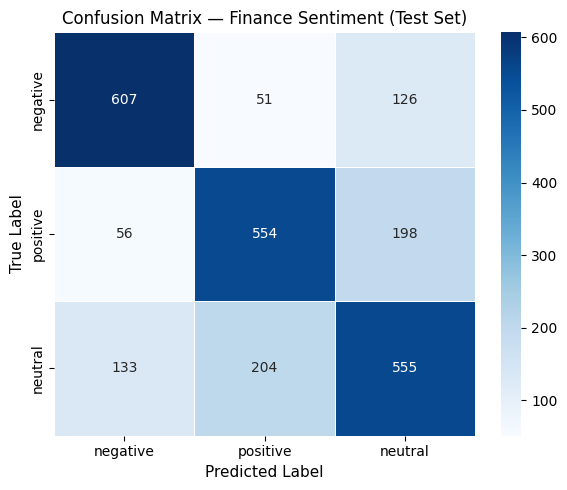

In [ ]:
# More metrics for report/presentation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

raw_preds = trainer.predict(tokenized_test)
y_pred    = np.argmax(raw_preds.predictions, axis=-1)
y_true    = raw_preds.label_ids

acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("\n── Test Set Performance ────────────────────────────")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Macro F1:  {macro_f1:.4f}")
print("\n  Per-class report:")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(3)]))

# Confusion Matrix
cm     = confusion_matrix(y_true, y_pred)
labels = [id2label[i] for i in range(3)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels, ax=ax,
    linewidths=0.5,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title("Confusion Matrix — Finance Sentiment (Test Set)", fontsize=12)
plt.tight_layout()
plt.show()

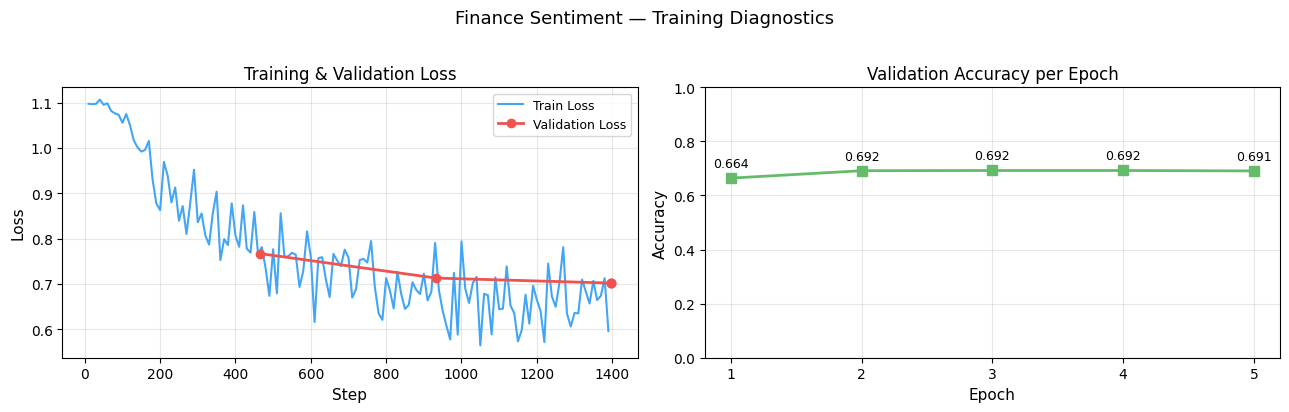

In [ ]:
# Training loss curve
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_entries = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_entries  = [e for e in log_history if "eval_loss" in e]

train_steps  = [e["step"] for e in train_entries]
train_losses = [e["loss"] for e in train_entries]

eval_steps  = [e["step"] for e in eval_entries]
eval_losses = [e["eval_loss"] for e in eval_entries]
eval_accs   = [e["eval_accuracy"] for e in eval_entries]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
axes[0].plot(train_steps, train_losses, label="Train Loss",      color="#42a5f5", linewidth=1.5)
axes[0].plot(eval_steps,  eval_losses,  label="Validation Loss", color="#ef5350",
             linewidth=2, marker="o", markersize=6)
axes[0].set_xlabel("Step", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].set_title("Training & Validation Loss", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Validation accuracy
epochs = list(range(1, len(eval_accs) + 1))
axes[1].plot(epochs, eval_accs, color="#66bb6a", linewidth=2, marker="s", markersize=7)
for e, a in zip(epochs, eval_accs):
    axes[1].annotate(f"{a:.3f}", (e, a), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_title("Validation Accuracy per Epoch", fontsize=12)
axes[1].set_xticks(epochs)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Finance Sentiment — Training Diagnostics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting fine-tuned embeddings...
Extracting base model embeddings...
Done.
Running t-SNE on fine-tuned embeddings...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Running t-SNE on base embeddings...
Done.


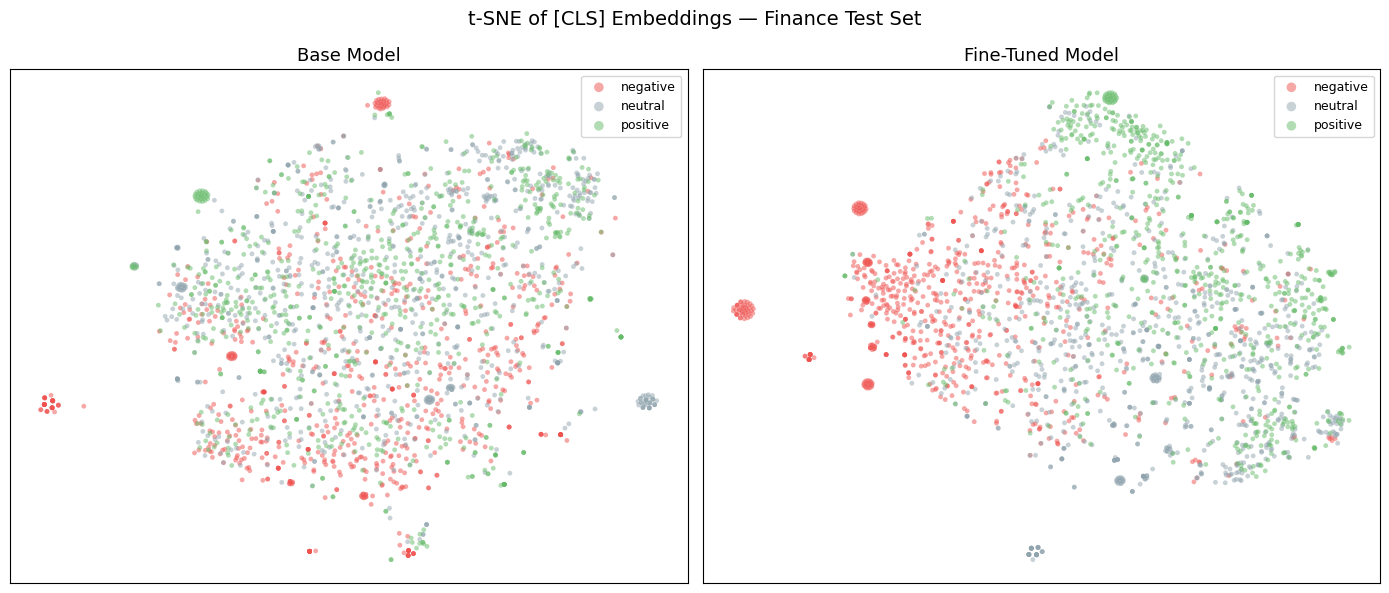

) missing from font(s) DejaVu Sans.8s5r40000gp/T/ipykernel_28357/1166249789.py:97: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans./.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


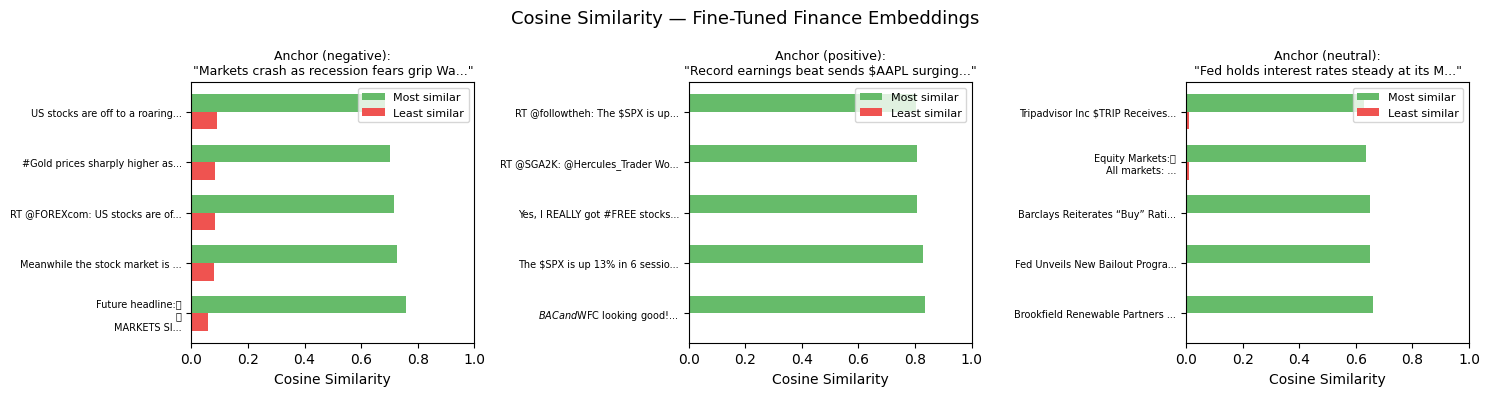

In [ ]:
# tSNE and cosine similarity

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

AMSC = AutoModelForSequenceClassification

def get_cls_embeddings(texts, mdl, tok, dev, batch_size=32):
    mdl.eval()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i + batch_size]
        inputs = tok(batch, return_tensors="pt", truncation=True,
                     max_length=128, padding=True).to(dev)
        with torch.no_grad():
            outputs = mdl(**inputs)
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

# Load a fresh copy of the base model with hidden-state output enabled
base_model_emb = AMSC.from_pretrained(
    "distilbert-base-uncased", num_labels=3, output_hidden_states=True
).to(device)
model.config.output_hidden_states = True

texts_test  = test_df["text"].tolist()
labels_test = test_df["sentiment_str"].tolist()

print("Extracting fine-tuned embeddings...")
ft_embeddings   = get_cls_embeddings(texts_test, model, tokenizer, device)
print("Extracting base model embeddings...")
base_embeddings = get_cls_embeddings(texts_test, base_model_emb, tokenizer, device)
print("Done.")


def run_tsne(embeddings):
    pca     = PCA(n_components=50, random_state=42)
    reduced = pca.fit_transform(embeddings)
    tsne    = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
    return tsne.fit_transform(reduced)

print("Running t-SNE on fine-tuned embeddings...")
ft_2d   = run_tsne(ft_embeddings)
print("Running t-SNE on base embeddings...")
base_2d = run_tsne(base_embeddings)
print("Done.")

label_colors = {"negative": "#ef5350", "neutral": "#90a4ae", "positive": "#66bb6a"}
label_array  = np.array(labels_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in zip(axes, [base_2d, ft_2d], ["Base Model", "Fine-Tuned Model"]):
    for sentiment, color in label_colors.items():
        mask = label_array == sentiment
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, label=sentiment, alpha=0.5, s=12, edgecolors='none')
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=2, fontsize=9)
fig.suptitle("t-SNE of [CLS] Embeddings — Finance Test Set", fontsize=14)
plt.tight_layout()
plt.show()

# Cosine Similarity
anchors = {
    "negative": "Markets crash as recession fears grip Wall Street and investors flee.",
    "positive": "Record earnings beat sends $AAPL surging to new all-time highs!",
    "neutral":  "Fed holds interest rates steady at its May policy meeting.",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sentiment, anchor_text) in zip(axes, anchors.items()):
    anchor_emb = get_cls_embeddings([anchor_text], model, tokenizer, device)
    sims       = cosine_similarity(anchor_emb, ft_embeddings)[0]

    ranked   = np.argsort(sims)[::-1]
    top5_idx = [i for i in ranked if texts_test[i] != anchor_text][:5]
    bot5_idx = ranked[-5:][::-1]

    y      = np.arange(5)
    height = 0.35

    ax.barh(y + height/2, sims[top5_idx], height, label='Most similar',  color='#66bb6a')
    ax.barh(y - height/2, sims[bot5_idx], height, label='Least similar', color='#ef5350')
    ax.set_yticks(y)
    ax.set_yticklabels([f"{texts_test[i][:30]}..." for i in top5_idx], fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Cosine Similarity')
    ax.set_title(f'Anchor ({sentiment}):\n"{anchor_text[:40]}..."', fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle("Cosine Similarity — Fine-Tuned Finance Embeddings", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Export dataset with dummy column "finance" to be combined with other subject datasets in the "Frankenstined" dataset for stage 1.

export_df = df[["text", "sentiment_str", "label"]].copy()
export_df["topic"] = "finance"
export_df = export_df.rename(columns={"sentiment_str": "sentiment"})

output_path = "finance_labelled_for_stage1.csv"
export_df.to_csv(output_path, index=False)
print(f"Exported {len(export_df)} rows to '{output_path}'")
print(export_df.head())

Exported 12420 rows to 'finance_labelled_for_stage1.csv'
                                                text sentiment  label    topic
0  @KennyDegu very very little volume. With $10T ...  negative      0  finance
1  #ES_F achieved Target 2780 closing above 50% #...   neutral      2  finance
2  RT @KimbleCharting: Silver/Gold indicator crea...  negative      0  finance
3  @Issaquahfunds Hedged our $MSFT position into ...  negative      0  finance
4  RT @zipillinois: 3 Surprisingly Controversial ...  positive      1  finance
